In [7]:
# -----------------------------
#Importing all dependencies
# -----------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore") 
sns.set_style("darkgrid", {"grid.color": ".6", 
                           "grid.linestyle": ":"})

from sklearn.preprocessing import StandardScaler 
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline 
from sklearn.linear_model import Lasso

from sklearn.ensemble import RandomForestRegressor 
from xgboost import XGBRegressor
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error 
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error



from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# About the dataset


Gold Price Prediction Dataset on Kaggle:
 https://www.kaggle.com/datasets/sid321axn/gold-price-prediction-dataset

This dataset contains historical gold price data (Date, Open, High, Low, Close, Adjusted Close, Volume, etc.) and is widely used for ML regression prediction tasks like RandomForestRegressor.

In [8]:
# -----------------------------
# 1. Download Gold data
# -----------------------------

gold = pd.read_csv("gld_price_data.csv",parse_dates=["Date"])

print(gold.head())

        Date          SPX        GLD        USO     SLV   EUR/USD
0 2008-01-02  1447.160034  84.860001  78.470001  15.180  1.471692
1 2008-01-03  1447.160034  85.570000  78.370003  15.285  1.474491
2 2008-01-04  1411.630005  85.129997  77.309998  15.167  1.475492
3 2008-01-07  1416.180054  84.769997  75.500000  15.053  1.468299
4 2008-01-08  1390.189941  86.779999  76.059998  15.590  1.557099


In [9]:
# Missing Values/Null Values Count
gold.isna().sum().sort_values(ascending=False)

Date       0
SPX        0
GLD        0
USO        0
SLV        0
EUR/USD    0
dtype: int64

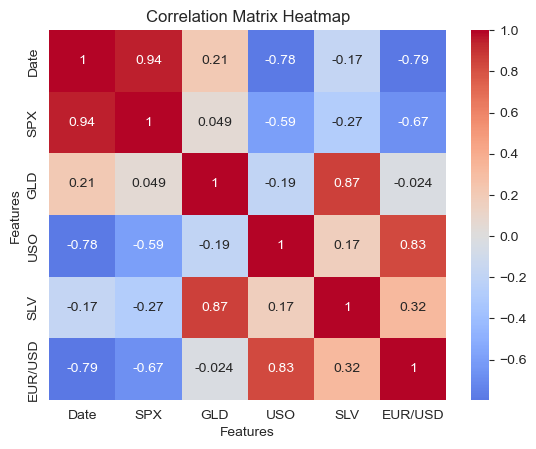

In [10]:
# Calculate correlation matrix
correlation=gold.corr() 

#create heatmap

# Create heatmap
sns.heatmap(correlation, cmap='coolwarm',
            center=0, annot=True)

# Set title and axis labels
plt.title('Correlation Matrix Heatmap')
plt.xlabel('Features')
plt.ylabel('Features')

# Show plot
plt.show()


Here the two columns SLV and GLD are strongly correlated with each other compared to others, here we will drop SLV since GLD column also has a large correlation with our target column. Here We have used the pandas Drop function to drop the column along axis=1.

In [11]:
# drop SlV column
gold.drop("SLV", axis=1,
             inplace=True)

In [12]:
# reset the index to date column
gold.set_index("Date", inplace=True)

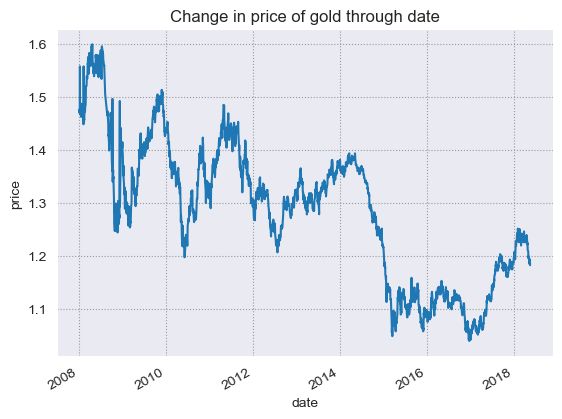

In [13]:
# plot price of gold for each increasing day
gold["EUR/USD"].plot()
plt.title("Change in price of gold through date")
plt.xlabel("date")
plt.ylabel("price")
plt.show()

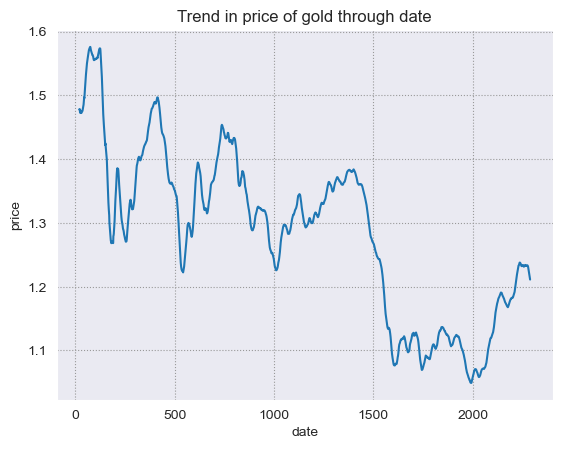

In [14]:
# apply rolling mean with window size of 3
gold["price_trend"] = gold["EUR/USD"]\
    .rolling(window=20).mean()

# reset the index to date column
gold.reset_index("Date", inplace=True)

# since we have used rolling method
# for 20 rows first 2 rows will be NAN
gold["price_trend"].loc[20:].plot()

# set title of the chart
plt.title("Trend in price of gold through date")

# set x_label of the plot
plt.xlabel("date")
plt.ylabel("price")
plt.show()

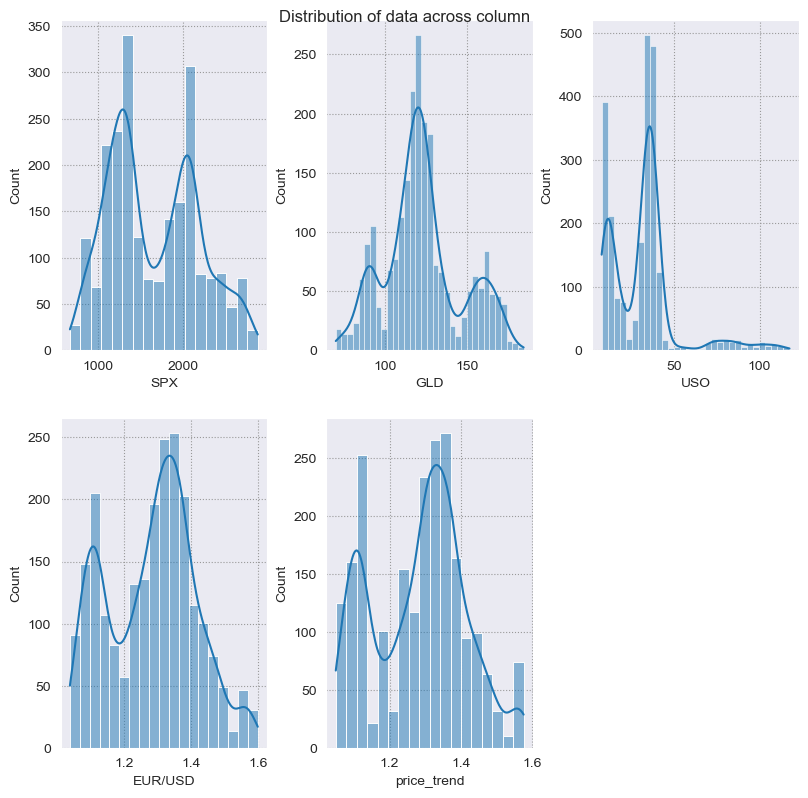

In [15]:
fig = plt.figure(figsize=(8, 8))

# suptitle of the graph
fig.suptitle('Distribution of data across column')
temp = gold.drop("Date", axis=1).columns.tolist()
for i, item in enumerate(temp):
    plt.subplot(2, 3, i+1)
    sns.histplot(data=gold, x=item, kde=True)
plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=2.0)
plt.show()

In [16]:
# skewness along the index axis
print(gold.drop("Date", axis=1).skew(axis=0, skipna=True))

SPX            0.300362
GLD            0.334138
USO            1.699331
EUR/USD       -0.005292
price_trend   -0.029588
dtype: float64


#Column USO has the highest skewness of 0.98, so here we will apply square root transformation on this column to reduce its skewness to 0. We can use different transformation functions to lower the skewness some are logarithmic transformation, inverse transformation, etc.

In [29]:
# apply saquare root transformation
# on the skewed dataset
gold["USO"] = gold["USO"]\
    .apply(lambda x: np.sqrt(x))

# Handling Outliers 
Outliers can have a very bad effect on our model like in linear regression if a data point is an outlier then it can add a very large mean square error. Removing outliers is a good process in EDA

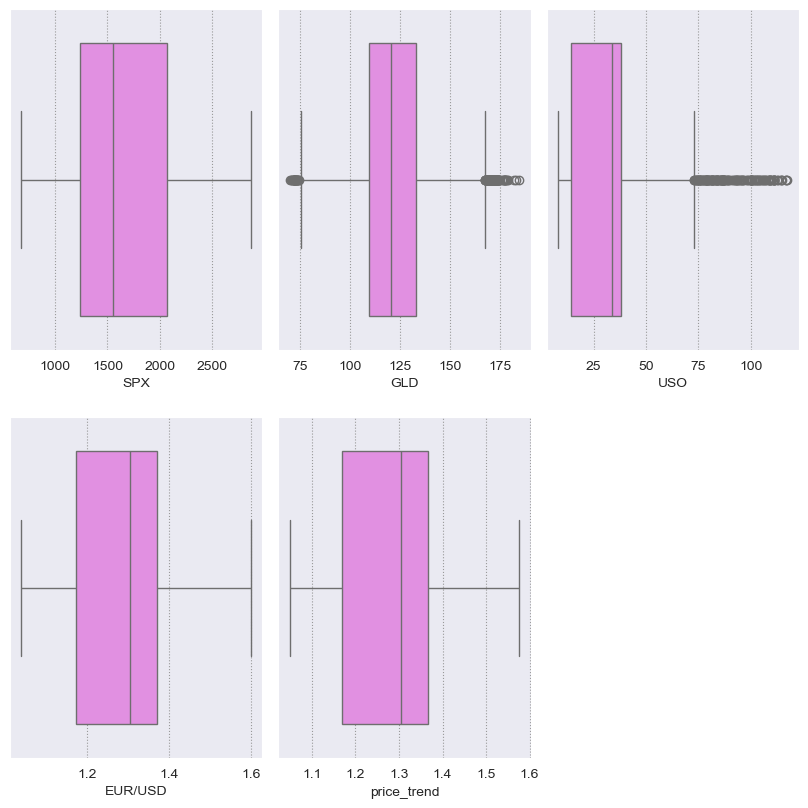

In [17]:
fig = plt.figure(figsize=(8, 8))
temp = gold.drop("Date", axis=1).columns.tolist()
for i, item in enumerate(temp):
    plt.subplot(2, 3, i+1)
    sns.boxplot(data=gold, x=item, color='violet')
plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=2.0)
plt.show()

In [18]:
def outlier_removal(column):
    # Capping the outlier rows with Percentiles
    upper_limit = column.quantile(.95)
    # set upper limit to 95percentile
    lower_limit = column.quantile(.05)
    # set lower limit to 5 percentile
    column.loc[(column > upper_limit)] = upper_limit
    column.loc[(column < lower_limit)] = lower_limit
    return column

In [19]:
# Normalize outliers in columns except Date

gold[['SPX', 'GLD', 'USO', 'EUR/USD']] = \
    gold[['SPX', 'GLD', 'USO', 'EUR/USD']].apply(outlier_removal)

In [21]:
# select the features and target variable
X = gold.drop(['Date', 'EUR/USD'], axis=1)

y = gold['EUR/USD']
# dividing dataset in to train test
x_train, x_test,\
    y_train, y_test = train_test_split(X, y,
                                       test_size=0.2)

In [24]:
# Create an instance of the StandardScaler
scaler = StandardScaler()

# Fit the StandardScaler on the training dataset
scaler.fit(x_train)

# Transform the training dataset
# using the StandardScaler
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [27]:
# Impute missing values using SimpleImputer
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean') # Replace NaNs with the mean of each column

# Fit and transform the imputer on the scaled training data
x_train_scaled = imputer.fit_transform(x_train_scaled)

# Transform the scaled test data using the trained imputer
x_test_scaled = imputer.transform(x_test_scaled)

# Create a PolynomialFeatures object of degree 2
poly = PolynomialFeatures(degree=2)

# Create a Lasso object
lasso = Lasso()

# Define a dictionary of parameter
#values to search over
param_grid = {'lasso__alpha': [1e-4, 1e-3, 1e-2,
							1e-1, 1, 5, 10, 
							20, 30, 40]}

# Create a pipeline that first applies 
# polynomial features and then applies Lasso regression
pipeline = make_pipeline(poly, lasso)

# Create a GridSearchCV object with 
#the pipeline and parameter grid
lasso_grid_search = GridSearchCV(pipeline,
								param_grid, 
								scoring='r2', cv=3)

# Fit the GridSearchCV object to the training data
lasso_grid_search.fit(x_train_scaled, y_train)

# Predict the target variable using
# the fitted model and the test data
y_pred_train = lasso_grid_search.predict(x_train_scaled)
y_pred_test= lasso_grid_search.predict(x_test_scaled)

# Compute the R-squared of the fitted model on the train data
r2 = r2_score(y_train, y_pred_train)

mae_lasso = mean_absolute_error(y_test, y_pred_test)
mse_lasso = mean_squared_error(y_test, y_pred_test)
rmse_lasso = np.sqrt(mse_lasso)


print("MAE:", mae_lasso)
print("MSE:", mse_lasso)
print("RMSE:", rmse_lasso)


# Print the R-squared
print("R-squared: ", r2)

# Print the best parameter values and score
print('Best parameter values: ',
	lasso_grid_search.best_params_)
print('Best score: ',
	lasso_grid_search.best_score_)

MAE: 0.016351233184686963
MSE: 0.000461499283844532
RMSE: 0.021482534390628402
R-squared:  0.9655751140393416
Best parameter values:  {'lasso__alpha': 0.0001}
Best score:  0.9644895861983978


In [28]:
# Insiate param grid for which to search
param_grid = {'n_estimators': [50, 80, 100],
              'max_depth': [3, 5, 7]}

# create instance of the Randomforest regressor
rf = RandomForestRegressor()

# Define Girdsearch with random forest
# object parameter grid scoring and cv
rf_grid_search = GridSearchCV(rf, param_grid, scoring='r2', cv=2)

# Fit the GridSearchCV object to the training data

rf_grid_search.fit(x_train_scaled, y_train)
# Predict the target variable using
# the fitted model and the test data


y_pred_train = rf_grid_search.predict(x_train_scaled)
y_pred_test= rf_grid_search.predict(x_test_scaled)


# Compute the R-squared of the fitted model on the train data
r2 = r2_score(y_train, y_pred_train)

mae_rf = mean_absolute_error(y_test, y_pred_test)
mse_rf = mean_squared_error(y_test, y_pred_test)
rmse_rf = np.sqrt(mse_rf)


print("MAE:", mae_rf)
print("MSE:", mse_rf)
print("RMSE:", rmse_rf)



# Print the best parameter values and score
print('Best parameter values: ', rf_grid_search.best_params_)
print('Best score: ', rf_grid_search.best_score_)

MAE: 0.012089753012330017
MSE: 0.00030581284738955716
RMSE: 0.017487505465032947
Best parameter values:  {'max_depth': 7, 'n_estimators': 50}
Best score:  0.9753341930513013


In [29]:
# Compute the R-squared of the
# fitted model on the test data
r2 = r2_score(y_test,
              rf_grid_search.predict(x_test_scaled))

# Print the R-squared
print("R-squared:", r2)

R-squared: 0.9808425363202387


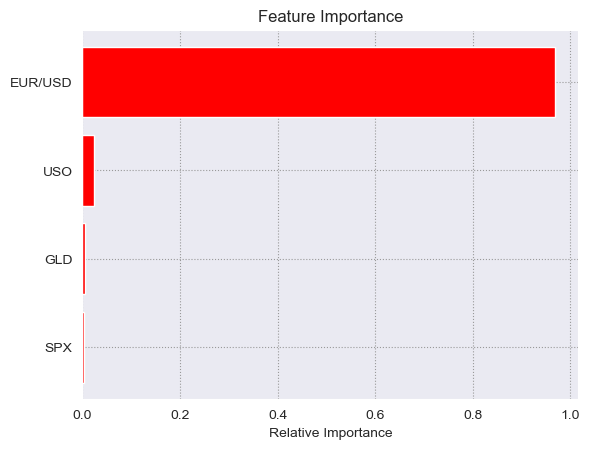

In [30]:
features = gold.drop("Date", axis=1).columns

# store the importance of the feature
importances = rf_grid_search.best_estimator_.\
    feature_importances_


indices = np.argsort(importances)

# title of the graph
plt.title('Feature Importance')

plt.barh(range(len(indices)),
         importances[indices],
         color='red',
         align='center')

# plot bar chart
plt.yticks(range(len(indices)),
           [features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

In [ ]:
# XGBoost Model for Regression 

In [32]:
# Create an instance of the XGBRegressor model
model_xgb = XGBRegressor()

# Fit the model to the training data
model_xgb.fit(x_train_scaled, y_train)

y_pred_train =model_xgb.predict(x_train_scaled)
y_pred_test= model_xgb.predict(x_test_scaled)



#calculate mae, mse, rmse , r2

mae_xgb = mean_absolute_error(y_test, y_pred_test)
mse_xgb = mean_squared_error(y_test, y_pred_test)
rmse_xgb = np.sqrt(mse_xgb)

print("MAE:", mae_xgb)
print("MSE:", mse_xgb)
print("RMSE:", rmse_xgb)


# Print the R-squared score on the training data
print("Xgboost Accuracy =", r2_score(
    y_train, model_xgb.predict(x_train_scaled)))

MAE: 0.009013961216289399
MSE: 0.00018156137852671706
RMSE: 0.013474471363534715
Xgboost Accuracy = 0.9995091922491827


In [33]:
# Print the R-squared score on the test data
print("Xgboost Accuracy on test data =",
      r2_score(y_test,
               model_xgb.predict(x_test_scaled)))

Xgboost Accuracy on test data = 0.9886261955818284


# comparision of three models in terms of MAE, MSE and RMSE

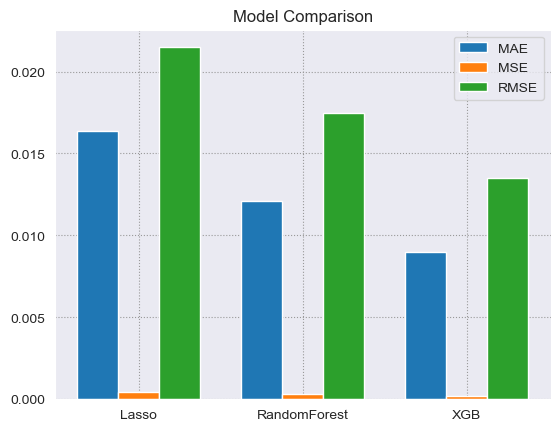

In [34]:


labels = ["Lasso", "RandomForest", "XGB"]

mae_vals = [mae_lasso, mae_rf, mae_xgb]
mse_vals = [mse_lasso, mse_rf, mse_xgb]
rmse_vals = [rmse_lasso, rmse_rf, rmse_xgb]

x = np.arange(len(labels))
width = 0.25

plt.figure()

plt.bar(x - width, mae_vals, width, label="MAE")
plt.bar(x, mse_vals, width, label="MSE")
plt.bar(x + width, rmse_vals, width, label="RMSE")

plt.xticks(x, labels)
plt.legend()
plt.title("Model Comparison")
plt.show()

# Intepretation

The performance of Lasso, Random Forest, and XGBoost models was compared using MAE, MSE, and RMSE.
All three models show similar performance.However, XGBoost consistently achieved the lowest error across all metrics, suggesting that it captures the nonlinear relationships in the data better than Lasso and Random Forest.
The differences between models are small, which suggests that the input features already explain most of the variance in the gold price. In such cases, complex models like XGBoost provide only marginal improvement over simpler models.

In [43]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense,  Dropout


# Selecting features

features = ["SPX", "USO", "EUR/USD"]
target = "GLD"
print(gold.columns)
data = gold[features + [target]]
print(data.head())

Index(['Date', 'SPX', 'GLD', 'USO', 'EUR/USD', 'price_trend'], dtype='object')
           SPX        USO   EUR/USD     GLD
0  1447.160034  77.978502  1.471692  86.816
1  1447.160034  77.978502  1.474491  86.816
2  1411.630005  77.309998  1.475492  86.816
3  1416.180054  75.500000  1.468299  86.816
4  1390.189941  76.059998  1.491295  86.816


In [47]:
# scale data

from sklearn.preprocessing import MinMaxScaler

scaler=MinMaxScaler()
scaled_data = scaler.fit_transform(data)
print(scaled_data.shape)

(2290, 4)


In [41]:
# -----------------------------
# 4. Create sequences for LSTM
# -----------------------------

X = []
y = []

time_step = 10

for i in range(time_step, len(scaled_data)):
    X.append(scaled_data[i-time_step:i])
    y.append(scaled_data[i,1])   # GLD column index = 1

X = np.array(X)
y = np.array(y)

In [44]:

# -----------------------------
# 5. Train test split
# -----------------------------

split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]


# -----------------------------
# 6. Build LSTM model
# -----------------------------

model = Sequential()

model.add(LSTM(50, return_sequences=True,
               input_shape=(X.shape[1], X.shape[2])))

model.add(Dropout(0.2))

model.add(LSTM(50))

model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

model.summary()


# -----------------------------
# 7. Train model
# -----------------------------

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)


# -----------------------------
# 8. Prediction
# -----------------------------

pred = model.predict(X_test)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 10, 50)         │        11,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,251 (122.07 KB)

 Trainable params: 31,251 (122.07 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0175 - val_loss: 2.5579e-04
Epoch 2/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0035 - val_loss: 3.9975e-04
Epoch 3/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0028 - val_loss: 2.1192e-04
Epoch 4/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0024 - val_loss: 1.0175e-04
Epoch 5/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0023 - val_loss: 3.2663e-04
Epoch 6/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0019 - val_loss: 5.2210e-04
Epoch 7/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0023 - val_loss: 1.1420e-04
Epoch 8/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0021 - val_loss: 1.1193e-04
Epoch 9/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0019 - val_loss: 4.3191e-04
Epoch 10/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0018 - val_loss: 1.1305e-04
Epoch 11/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0019 - val_loss: 1.6273e-04
Epoch 12/20
57/57 ━━━━━━━━━━━━

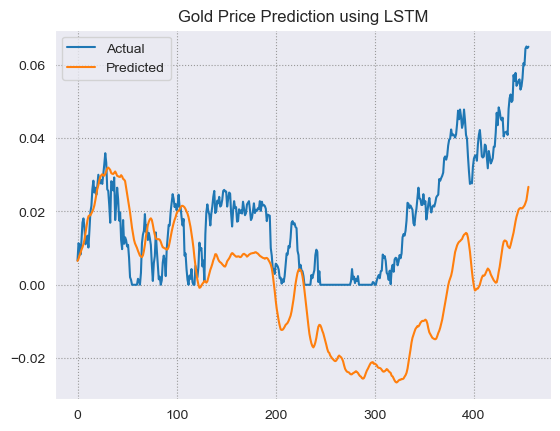

In [45]:
# -----------------------------
# 9. Plot results
# -----------------------------

plt.plot(y_test, label="Actual")
plt.plot(pred, label="Predicted")

plt.legend()
plt.title("Gold Price Prediction using LSTM")

plt.show()

In [48]:
pred_full = np.zeros((len(pred), 4))
y_test_full = np.zeros((len(pred), 4))

pred_full[:,1] = pred[:,0]
y_test_full[:,1] = y_test

pred_inv = scaler.inverse_transform(pred_full)[:,1]
y_test_inv = scaler.inverse_transform(y_test_full)[:,1]

In [50]:
# Calculation of error

mae = mean_absolute_error(y_test_inv, pred_inv)

mse = mean_squared_error(y_test_inv, pred_inv)

rmse = np.sqrt(mse)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)

MAE: 1.3343343990440832
MSE: 2.4955757470833686
RMSE: 1.5797391389350866


# Intepretation

We compared Linear Regression, Decision Tree, Random Forest, XGBoost, and LSTM using MAE, MSE, and RMSE.
Although LSTM is designed for time-series forecasting, it did not outperform XGBoost and Random Forest in this dataset.
This is because the gold price dataset behaves more like tabular regression with strong dependence on financial indicators (SPX, USO, SLV, EUR/USD) rather than long sequential patterns.
Tree-based ensemble models such as XGBoost handle tabular data very efficiently and therefore achieved lower error.